In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir
from embedding_utils import perform_pca_on_embeddings
from annotation_utils import load_marcotte_subtypes
from training_configuration import PATHWAYS_3C

data = "dream_cytof"

evaluations_dir = basedir / "eval_p38_v2"

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure3c.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3C
    ]
)

# Only keep central values
N_HIDDEN = 8
embedding_df = embedding_df[
    (embedding_df.depth == 0) & (embedding_df.n_hidden == N_HIDDEN)
]


subtypes_marcotte = load_marcotte_subtypes(embedding_df.cell_line.unique())

pca_embeddings_dict = {}
for model in PATHWAYS_3C:
    # print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model], n_components=N_HIDDEN)


for model in PATHWAYS_3C:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

Explained variance for cytof_init BT20: [0.38448512 0.17635863 0.13802847 0.10823589 0.06895943 0.04840469
 0.03870241 0.01726754]; Total: 0.9804
Explained variance for cytof_init EVSAT: [0.32435144 0.20979809 0.14961179 0.12344904 0.07050232 0.05318481
 0.03076021 0.01457938]; Total: 0.9762
Explained variance for cytof_init HCC1500: [0.31937464 0.21499647 0.13045293 0.10415223 0.08290784 0.06450275
 0.04706261 0.0250327 ]; Total: 0.9885
Explained variance for cytof_init HCC2185: [0.37291253 0.18518735 0.14547525 0.09609679 0.0707102  0.06165935
 0.03222957 0.01768843]; Total: 0.9820
Explained variance for cytof_init MCF7: [0.34451403 0.23816536 0.16068684 0.08137308 0.06910574 0.04429069
 0.0322148  0.01897487]; Total: 0.9893
Explained variance for cytof_init UACC3199: [0.30799095 0.19594613 0.16067374 0.11047218 0.07701363 0.06184999
 0.03545911 0.02219603]; Total: 0.9716
Explained variance for cytof_init UACC893: [0.42436172 0.15737142 0.12168166 0.10681547 0.06665148 0.05153761
 0.

In [2]:
embedding_df

,cell_line,L1,context,samples,dataset,job,n_hidden,depth,dropout_rate,l1reg_inflater_output,...,L22,L23,L24,L25,L26,L27,L28,L29,L30,model
14820,c184A1,-0.046923,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14821,c184B5,-0.263869,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14822,cAU565,-0.018232,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14823,cBT474,0.241893,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14824,cBT483,0.358532,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129915,cUACC3199,0.695101,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129916,cUACC812,0.536255,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129917,cUACC893,-0.014209,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129918,cZR751,0.475155,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg


In [3]:
pca_embedding_df = pd.concat(
    [
        pca_embeddings_dict[model].assign(model=model)
        for model in PATHWAYS_3C
    ]
)

In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from itertools import combinations


def compute_pca_group_separation(
    pca_embedding_df,
    model_order,
    context_order,
    pca_components,
    group_col,
    mode="categorical",        # "categorical" or "quantile"
    category_levels=None,      # used if mode == "categorical"
    n_quantiles=3,             # used if mode == "quantile"
    quantile_labels=None,      # optional; else auto Q1..Qk
    samples_col="samples",
    samples_value="all",
    verbose=False,
):
    """
    Compute ANOVA and pairwise Cohen's d for PCA directions across levels
    of a grouping variable, per (model, context).

    Parameters
    ----------
    pca_embedding_df : pd.DataFrame
        Table with PCA components, model, context, and grouping variable.
    model_order : list
        Models to iterate over.
    context_order : list
        Contexts to iterate over.
    pca_components : list
        Column names of PCA components (e.g. ["L1", "L2", ...]).
    group_col : str
        Column name to use for grouping (e.g. "tEGFR", "luminalbasal").
    mode : {"categorical", "quantile"}
        - "categorical": use group_col as-is (or restricted to category_levels).
        - "quantile": qcut group_col into n_quantiles.
    category_levels : list or None
        Explicit order of levels if mode == "categorical".
        If None, inferred from data.
    n_quantiles : int
        Number of quantiles if mode == "quantile".
    quantile_labels : list or None
        Labels for quantiles; if None, use ["Q1", ..., f"Q{n_quantiles}"].
    samples_col : str
        Column that indicates sample subset (e.g. "samples").
    samples_value : str
        Value in samples_col to keep (e.g. "all").
    verbose : bool
        If True, print basic info per (model, context).

    Returns
    -------
    anova_df : pd.DataFrame
        Columns: ["model", "context", "component", "F_stat", "p_value"].
    pairwise_df : pd.DataFrame
        Columns: ["model", "context", "component", "level1", "level2", "cohens_d"].
    """

    anova_rows = []
    pairwise_rows = []

    for model in model_order:
        for context in context_order:
            # Subset to this model, context, and sample subset
            df_mc = pca_embedding_df[
                (pca_embedding_df[samples_col] == samples_value)
                & (pca_embedding_df["model"] == model)
                & (pca_embedding_df["context"] == context)
            ].copy()

            if df_mc.empty:
                if verbose:
                    print(f"[WARN] No rows for model={model}, context={context}")
                continue

            # Decide grouping variable
            if mode == "quantile":
                # Build quantile labels
                if quantile_labels is None:
                    q_labels = [f"Q{i+1}" for i in range(n_quantiles)]
                else:
                    q_labels = quantile_labels

                group_var = f"{group_col}_q"

                # qcut on the continuous column
                df_mc[group_var] = pd.qcut(
                    df_mc[group_col],
                    q=n_quantiles,
                    labels=q_labels,
                    duplicates="drop",
                )
                # Levels that actually appear (avoid empty ones)
                levels = [lvl for lvl in q_labels if lvl in df_mc[group_var].unique()]

            elif mode == "categorical":
                group_var = group_col
                if category_levels is not None:
                    levels = [lvl for lvl in category_levels if lvl in df_mc[group_var].unique()]
                else:
                    # infer from data
                    levels = list(df_mc[group_var].dropna().unique())
            else:
                raise ValueError("mode must be either 'categorical' or 'quantile'")

            if verbose:
                print(f"\n=== model={model}, context={context} ===")
                print(f"Grouping on {group_var} with levels: {levels}")
                print(df_mc[group_var].value_counts(dropna=False))

            # Loop over PCA components
            for comp in pca_components:
                if comp not in df_mc.columns:
                    # No such component for this subset
                    anova_rows.append({
                        "model": model,
                        "context": context,
                        "component": comp,
                        "F_stat": np.nan,
                        "p_value": np.nan,
                    })
                    continue

                # --- 1) Overall ANOVA across all levels ---
                groups_for_anova = []
                for lvl in levels:
                    vals = df_mc.loc[df_mc[group_var] == lvl, comp].dropna()
                    if len(vals) > 1:  # need at least 2 to estimate variance
                        groups_for_anova.append(vals)

                if len(groups_for_anova) >= 2:
                    F_stat, p_val = stats.f_oneway(*groups_for_anova)
                else:
                    F_stat, p_val = np.nan, np.nan

                anova_rows.append({
                    "model": model,
                    "context": context,
                    "component": comp,
                    "F_stat": F_stat,
                    "p_value": p_val,
                })

                # --- 2) Pairwise Cohen's d for each pair of levels ---
                for level1, level2 in combinations(levels, 2):
                    g1 = df_mc.loc[df_mc[group_var] == level1, comp].dropna()
                    g2 = df_mc.loc[df_mc[group_var] == level2, comp].dropna()

                    n1, n2 = len(g1), len(g2)
                    if n1 < 2 or n2 < 2:
                        cohens_d = np.nan
                    else:
                        s1_std, s2_std = g1.std(ddof=1), g2.std(ddof=1)
                        s_pooled = np.sqrt(
                            ((n1 - 1) * s1_std**2 + (n2 - 1) * s2_std**2)
                            / (n1 + n2 - 2)
                        )
                        if s_pooled == 0 or np.isnan(s_pooled):
                            cohens_d = np.nan
                        else:
                            cohens_d = abs((g1.mean() - g2.mean()) / s_pooled)

                    pairwise_rows.append({
                        "model": model,
                        "context": context,
                        "component": comp,
                        "level1": level1,
                        "level2": level2,
                        "cohens_d": cohens_d,
                    })

    anova_df = pd.DataFrame(anova_rows)
    pairwise_df = pd.DataFrame(pairwise_rows)

    return anova_df, pairwise_df

# Embeddings annotated by Luminal/Basal

## First 2 PCA components only

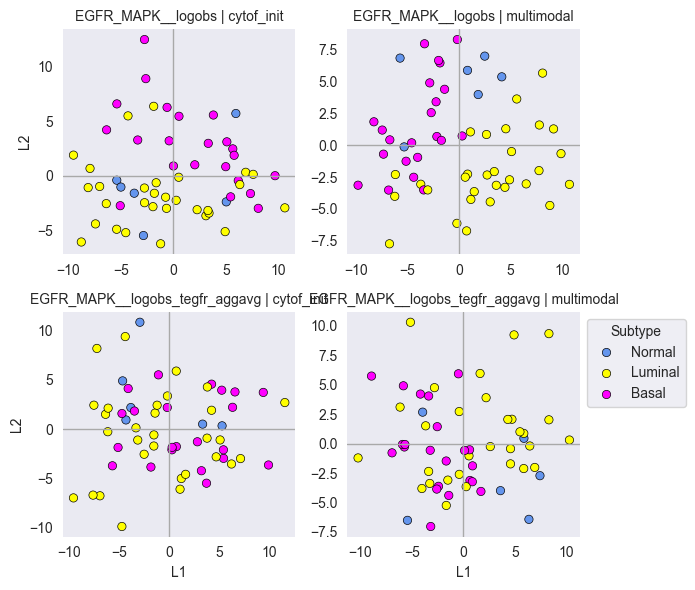

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Legend
plt.legend(title="Subtype", bbox_to_anchor=(1, 1))

# plt.savefig("fig1a_embeddings_allcontexts_onlyBT20split_LB_fixedge.svg")
plt.show()

## Check Luminal/Basal distributions across all PCA-ed latent components

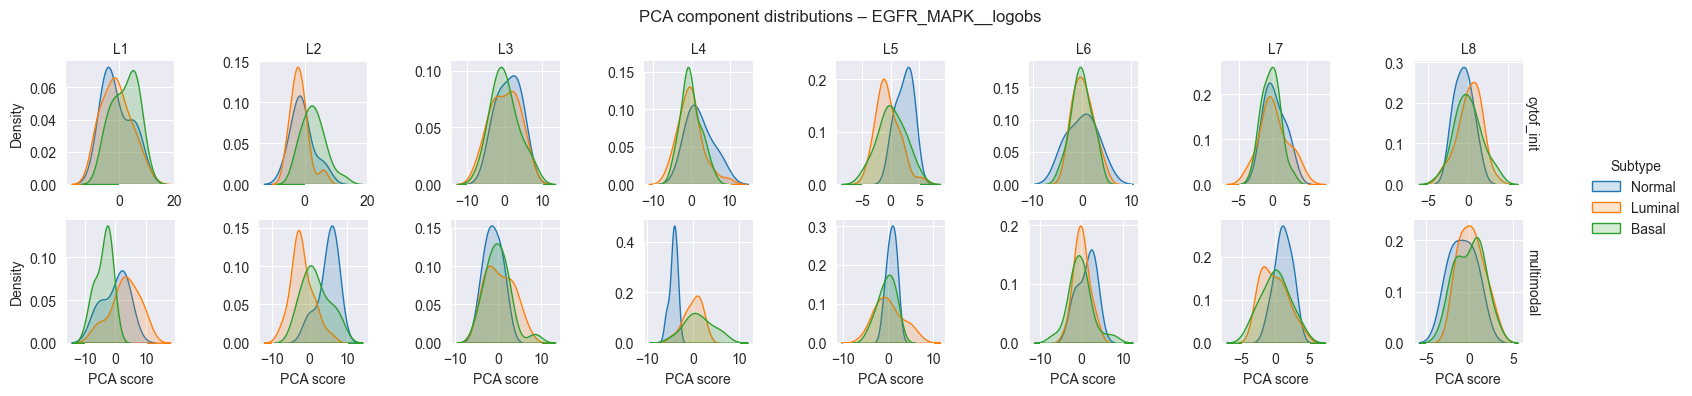

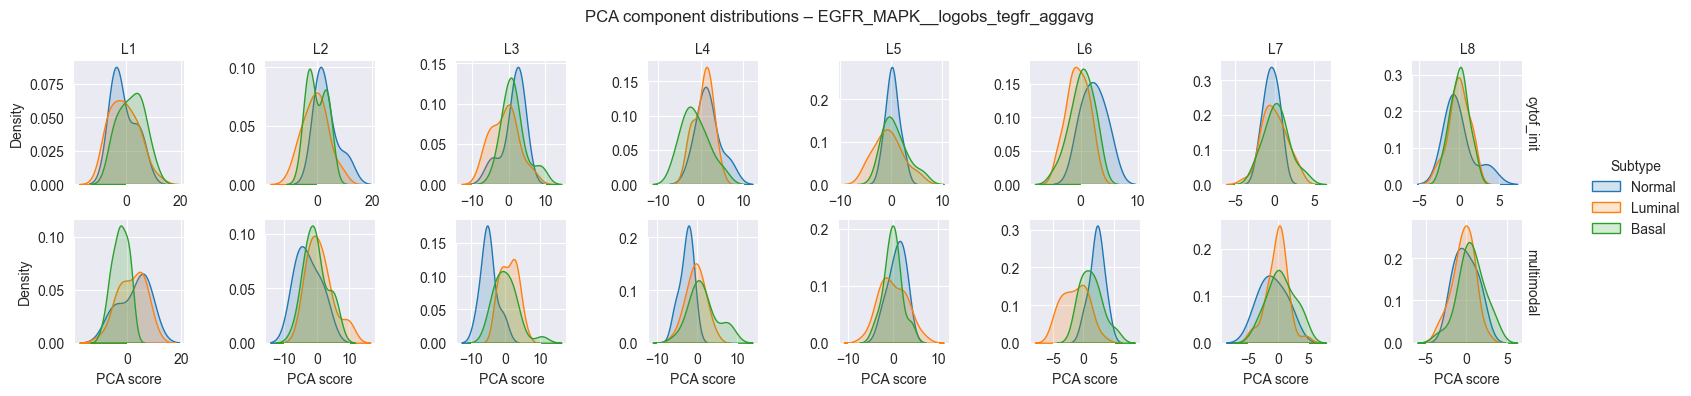

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "luminalbasal"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="luminalbasal",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="Subtype")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

## Evaluate which PCA-ed latent direction best separates subtypes: first pair-wise, then three-way ANOVA with pairwise Cohen's d

In [7]:
import numpy as np
import pandas as pd

pca_components = [f"L{i}" for i in range(1, 9)]

results = []

for model in model_order:
    for context in context_order:
        # Subset just this model, this context, and "all" samples
        df_mc = pca_embedding_df[
            (pca_embedding_df["samples"] == "all")
            & (pca_embedding_df["model"] == model)
            & (pca_embedding_df["context"] == context)
        ].copy()

        if df_mc.empty:
            print(f"[WARN] No rows for model={model}, context={context}")
            continue

        # Optional sanity check
        print(f"\n=== model={model}, context={context} ===")
        print(df_mc["luminalbasal"].value_counts(dropna=False))

        for comp in pca_components:
            if comp not in df_mc.columns:
                # skip if PCA component not present for this subset
                results.append({
                    "model": model,
                    "context": context,
                    "component": comp,
                    "cohens_d": np.nan,
                })
                continue

            g1 = df_mc[df_mc["luminalbasal"] == "Luminal"][comp]
            g2 = df_mc[df_mc["luminalbasal"] == "Basal"][comp]

            n1, n2 = len(g1), len(g2)
            if n1 < 2 or n2 < 2:
                # too few samples to estimate variance
                cohens_d = np.nan
            else:
                s1, s2 = g1.std(ddof=1), g2.std(ddof=1)
                s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
                if s_pooled == 0 or np.isnan(s_pooled):
                    cohens_d = np.nan
                else:
                    cohens_d = abs((g1.mean() - g2.mean()) / s_pooled)

            results.append({
                "model": model,
                "context": context,
                "component": comp,
                "cohens_d": cohens_d,
            })

# Combine everything
results_df = pd.DataFrame(results)

# Example: show best-separated components per (model, context)
for model in model_order:
    for context in context_order:
        sub = (
            results_df[
                (results_df["model"] == model)
                & (results_df["context"] == context)
            ]
            .sort_values("cohens_d", ascending=False)
        )
        print(f"\n### model={model}, context={context}")
        print(sub)


=== model=EGFR_MAPK__logobs, context=cytof_init ===
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs, context=multimodal ===
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=cytof_init ===
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=multimodal ===
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

### model=EGFR_MAPK__logobs, context=cytof_init
               model     context component  cohens_d
1  EGFR_MAPK__logobs  cytof_init        L2  1.356575
0  EGFR_MAPK__logobs  cytof_init        L1  0.604466
4  EGFR_MAPK__logobs  cytof_init        L5  0.304714
6  EGFR_MAPK__logobs  cytof_init        L7  0.268648
5  EGFR_MAPK__logobs  cytof_init        L6  0.172685
7  EGFR_MAPK__logobs  cytof_init        L8  0.117351
3  EGFR_MAPK__logo

In [8]:
pca_components = [f"L{i}" for i in range(1, 9)]

anova_df, pairwise_df = compute_pca_group_separation(
    pca_embedding_df=pca_embedding_df,
    model_order=model_order,
    context_order=context_order,
    pca_components=pca_components,
    group_col="luminalbasal",
    mode="categorical",
    category_levels=["Luminal", "Basal", "Normal"],
    samples_col="samples",
    samples_value="all",
    verbose=True,
)


=== model=EGFR_MAPK__logobs, context=cytof_init ===
Grouping on luminalbasal with levels: ['Luminal', 'Basal', 'Normal']
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs, context=multimodal ===
Grouping on luminalbasal with levels: ['Luminal', 'Basal', 'Normal']
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=cytof_init ===
Grouping on luminalbasal with levels: ['Luminal', 'Basal', 'Normal']
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=multimodal ===
Grouping on luminalbasal with levels: ['Luminal', 'Basal', 'Normal']
luminalbasal
Luminal    30
Basal      22
Normal      6
Name: count, dtype: int64


In [9]:
anova_df

,model,context,component,F_stat,p_value
0,EGFR_MAPK__logobs,cytof_init,L1,2.443130,9.626669e-02
1,EGFR_MAPK__logobs,cytof_init,L2,11.672439,5.952266e-05
2,EGFR_MAPK__logobs,cytof_init,L3,0.205715,8.146882e-01
3,EGFR_MAPK__logobs,cytof_init,L4,1.675309,1.966636e-01
4,EGFR_MAPK__logobs,cytof_init,L5,4.604839,1.415664e-02
5,EGFR_MAPK__logobs,cytof_init,L6,0.173202,8.414249e-01
6,EGFR_MAPK__logobs,cytof_init,L7,0.531921,5.904667e-01
7,EGFR_MAPK__logobs,cytof_init,L8,0.636912,5.327792e-01
8,EGFR_MAPK__logobs,multimodal,L1,18.599993,6.758890e-07
9,EGFR_MAPK__logobs,multimodal,L2,15.832337,3.709505e-06


In [10]:
from statsmodels.stats.multitest import multipletests

anova_df["p_adj"] = np.nan

for (model, context), sub in anova_df.groupby(["model", "context"]):
    # Extract raw p-values
    pvals = sub["p_value"].values

    # Adjust using BH/FDR
    _, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

    # Write them back
    anova_df.loc[sub.index, "p_adj"] = pvals_adj

## The degree of separation, given by `F_stat`, is clearly much stronger in `multimodal`, and decreases going from `base` to `tEGFR`

In [11]:
best_components = (
    anova_df
    .loc[anova_df.groupby(["model", "context"])["F_stat"].idxmax()]
    .sort_values(["model", "context"])
)

best_components.sort_values("F_stat", ascending=False)


,model,context,component,F_stat,p_value,p_adj
8,EGFR_MAPK__logobs,multimodal,L1,18.599993,6.758890e-07,0.000005
29,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,L6,16.581359,2.315460e-06,0.000019
1,EGFR_MAPK__logobs,cytof_init,L2,11.672439,5.952266e-05,0.000476
21,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,L6,5.166222,8.788791e-03,0.041001


...but cannot detect any difference between the distributions of `F_stat` for the same `context` across `model` variants

In [12]:
from scipy.stats import ks_2samp

def compare_models_KS(results_df, context, modelA, modelB, score_col="F_stat"):
    vecA = results_df.query("context == @context and model == @modelA")[score_col].dropna()
    vecB = results_df.query("context == @context and model == @modelB")[score_col].dropna()
    stat, p = ks_2samp(vecA, vecB)
    return stat, p

stat, p = compare_models_KS(anova_df, "cytof_init",
                            "EGFR_MAPK__logobs",
                            "EGFR_MAPK__logobs_tegfr_aggavg",
                            score_col="F_stat")

print("KS stat:", stat, "p:", p)

KS stat: 0.375 p: 0.6601398601398599


In [13]:
from scipy.stats import ttest_ind

def compare_models_ttest(results_df, context, modelA, modelB, score_col="F_stat"):
    vecA = results_df.query("context == @context and model == @modelA")[score_col].dropna()
    vecB = results_df.query("context == @context and model == @modelB")[score_col].dropna()
    stat, p = ttest_ind(vecA, vecB, equal_var=False)
    return stat, p

compare_models_ttest(
    anova_df,
    "multimodal",
    "EGFR_MAPK__logobs",
    "EGFR_MAPK__logobs_tegfr_aggavg",
    score_col="F_stat"
)

(0.19296977382086478, 0.8500857377573646)

 # Check association with EGFR transcript levels

In [14]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = pca_embedding_df.index.unique().values
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs", data="dream_cytof"))
del petab_base_files["condition_table"]

cytof_init, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)
pp38 = cytof_init["p.p38"]
pp38 -= pp38.mean()
pp90rsk = cytof_init["p.p90RSK"]
pp90rsk -= pp90rsk.mean()
pmek = cytof_init["p.MEK"]
pmek -= pmek.mean()
del cytof_init

transcriptomics, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
tpls3 = transcriptomics["PLS3"]
tpls3 -= tpls3.mean()
del transcriptomics

proteomics, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= proteomics.mean()
pisoc1 = proteomics["ISOC1"]
pisoc1 -= pisoc1.mean()
del proteomics

In [15]:
pca_embedding_df["p.p38"] = pp38.loc[pca_embedding_df.index]
pca_embedding_df["p.p90RSK"] = pp90rsk.loc[pca_embedding_df.index]
pca_embedding_df["p.MEK"] = pmek.loc[pca_embedding_df.index]
pca_embedding_df["tEGFR"] = tegfr.loc[pca_embedding_df.index]
pca_embedding_df["pEGFR"] = pegfr.loc[pca_embedding_df.index]
pca_embedding_df["pISOC1"] = pisoc1.loc[pca_embedding_df.index]
pca_embedding_df["tPLS3"] = tpls3.loc[pca_embedding_df.index]

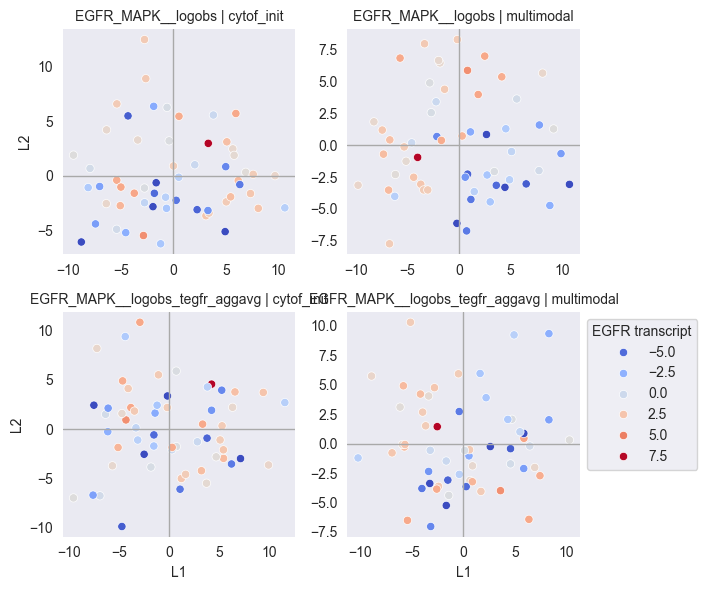

In [16]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="tEGFR",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="EGFR transcript", bbox_to_anchor=(1, 1))
# plt.savefig("fig1a_embeddings_allcontexts_onlyBT20split_tEGFR_fix.svg")

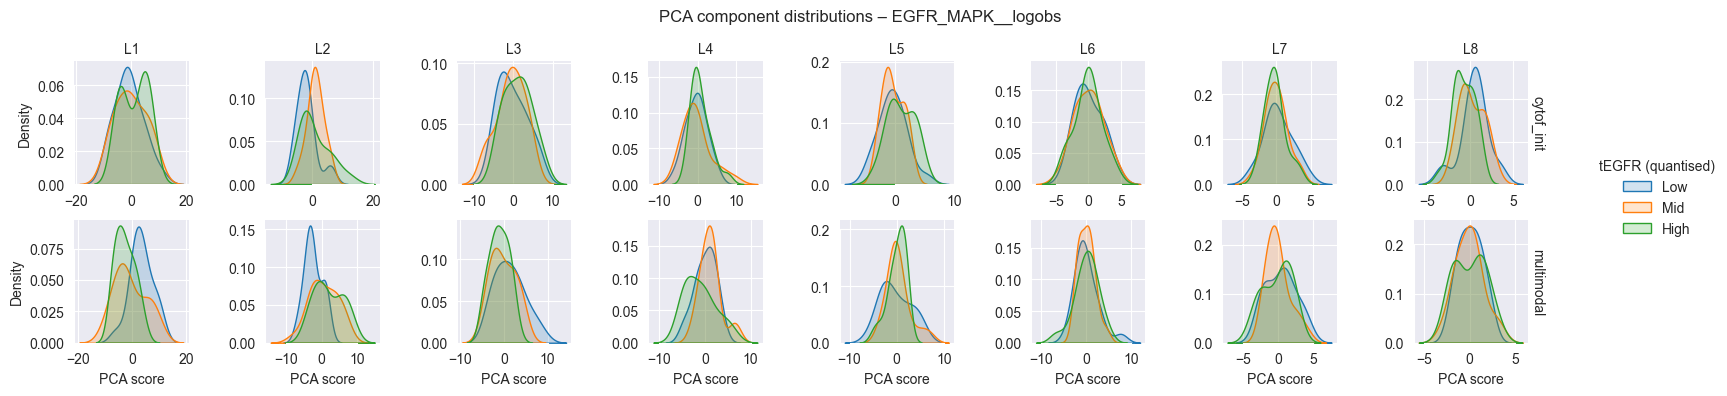

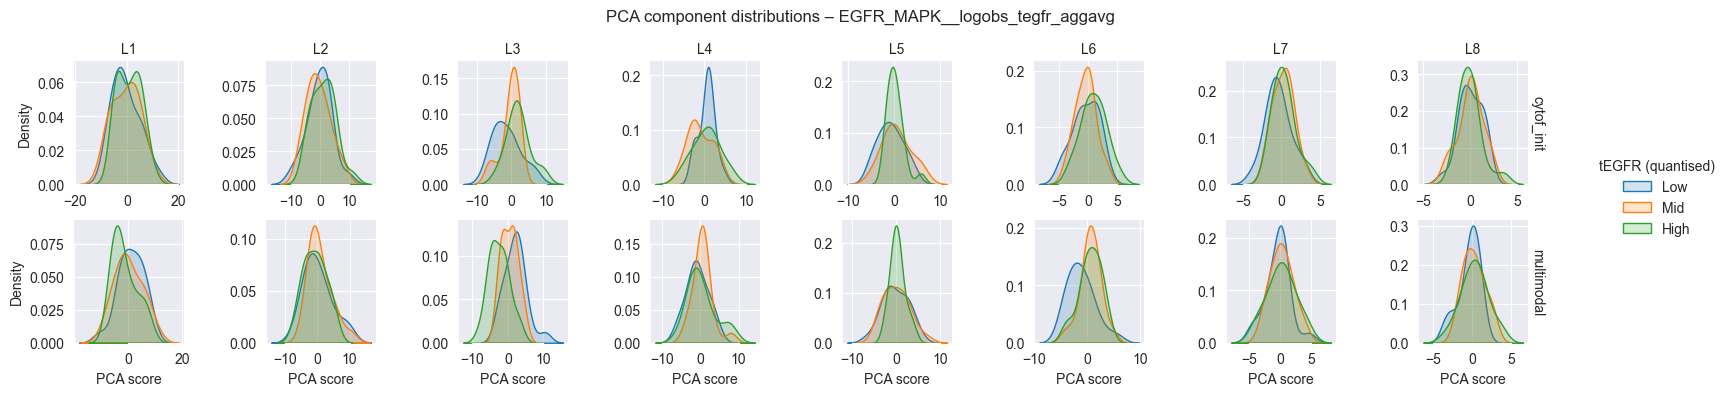

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Quantise tEGFR into quartiles (Q1–Q4)
    df_model["tEGFR_q"] = pd.qcut(
        df_model["tEGFR"],
        q=3,
        labels=["Low", "Mid", "High"]
    )

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "tEGFR_q"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="tEGFR_q",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="tEGFR (quantised)")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

In [18]:
pca_components = [f"L{i}" for i in range(1, 9)]

anova_df, pairwise_df = compute_pca_group_separation(
    pca_embedding_df=pca_embedding_df,
    model_order=model_order,
    context_order=context_order,
    pca_components=pca_components,
    group_col="tEGFR",
    mode="quantile",
    n_quantiles=3,
    quantile_labels=["Low", "Mid", "High"],
    samples_col="samples",
    samples_value="all",
    verbose=True,
)


=== model=EGFR_MAPK__logobs, context=cytof_init ===
Grouping on tEGFR_q with levels: ['Low', 'Mid', 'High']
tEGFR_q
Mid     20
Low     19
High    19
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs, context=multimodal ===
Grouping on tEGFR_q with levels: ['Low', 'Mid', 'High']
tEGFR_q
Mid     20
Low     19
High    19
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=cytof_init ===
Grouping on tEGFR_q with levels: ['Low', 'Mid', 'High']
tEGFR_q
Mid     20
Low     19
High    19
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=multimodal ===
Grouping on tEGFR_q with levels: ['Low', 'Mid', 'High']
tEGFR_q
Mid     20
Low     19
High    19
Name: count, dtype: int64


In [19]:
best_components = (
    anova_df
    .loc[anova_df.groupby(["model", "context"])["F_stat"].idxmax()]
    .sort_values(["model", "context"])
)

best_components.sort_values("F_stat", ascending=False)

,model,context,component,F_stat,p_value
26,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,L3,13.434097,0.000018
8,EGFR_MAPK__logobs,multimodal,L1,7.850962,0.001001
18,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,L3,4.332773,0.017890
1,EGFR_MAPK__logobs,cytof_init,L2,3.667124,0.031988


## Seems like the separation of tEGFR (quantised in Low/Mid/High) actually increases from `base` to `tEGFR` model, but not in the first two PCA directions! Let's take a look at L3

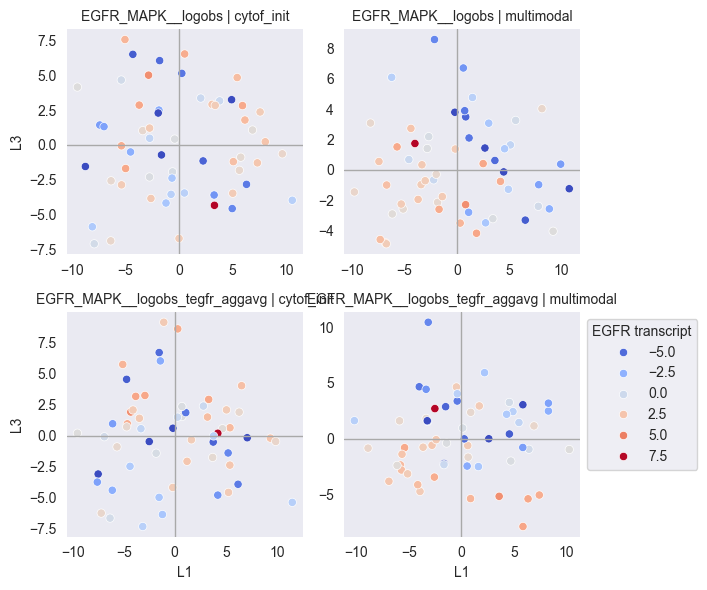

In [20]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L3",
    hue="tEGFR",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L3")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="EGFR transcript", bbox_to_anchor=(1, 1))
# plt.savefig("fig1a_embeddings_allcontexts_onlyBT20split_tEGFR_fix.svg")

# Check phospho-p90RSK at time 0

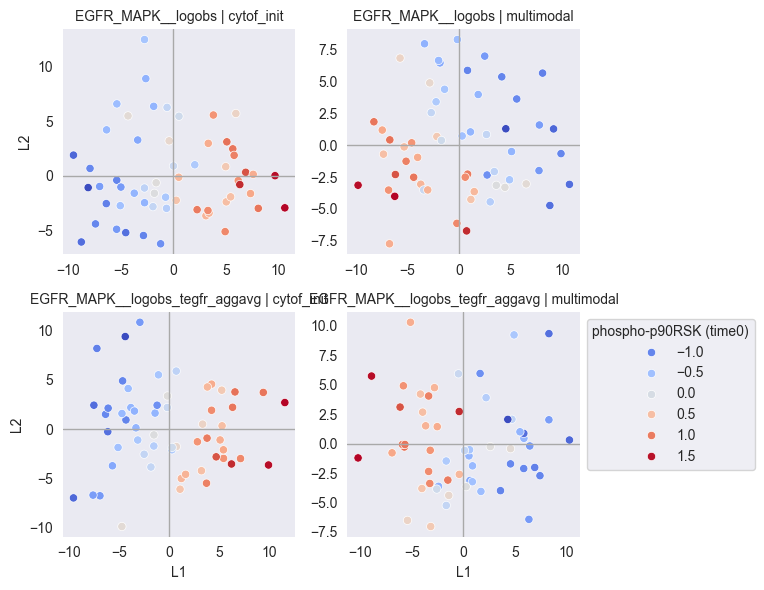

In [21]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="phospho-p90RSK (time0)", bbox_to_anchor=(1, 1))

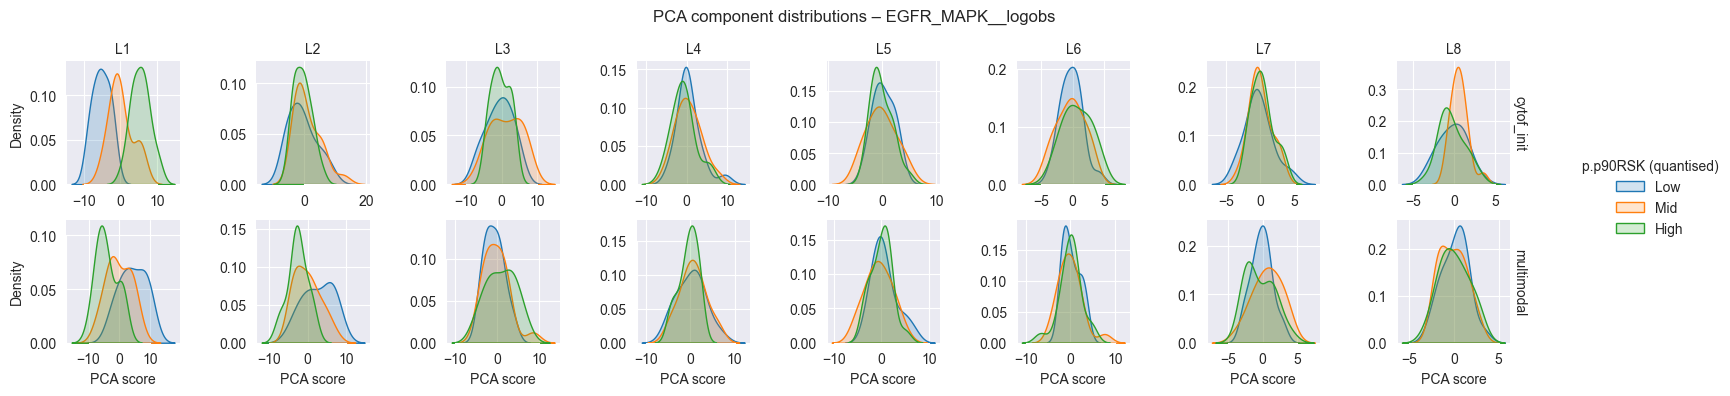

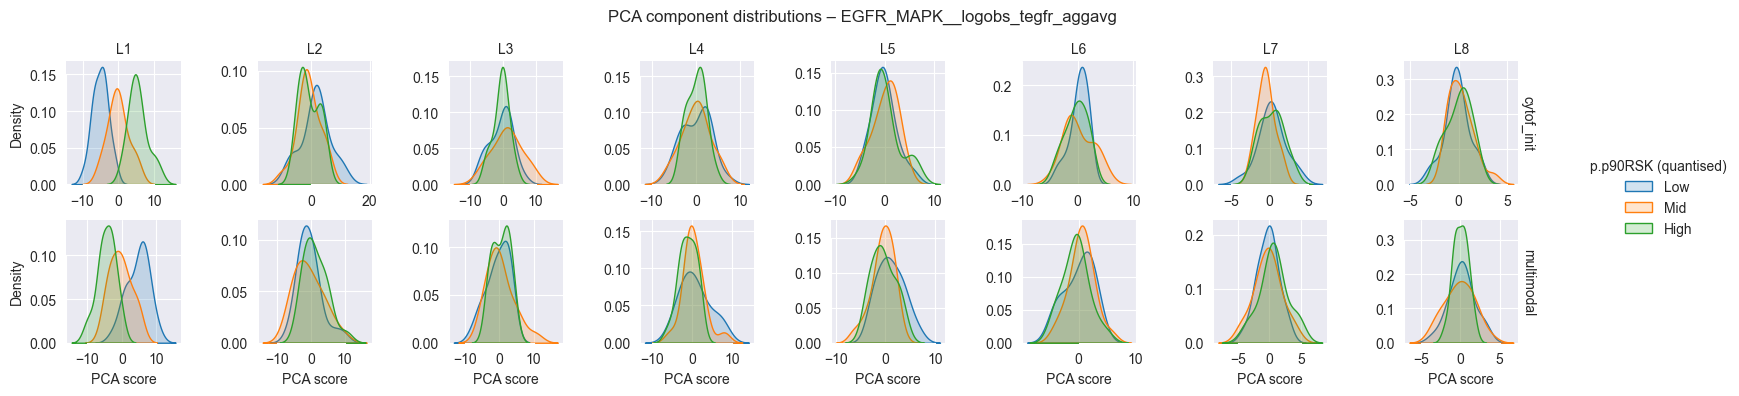

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Quantise tEGFR into quartiles (Q1–Q4)
    df_model["p.p90RSK_q"] = pd.qcut(
        df_model["p.p90RSK"],
        q=3,
        labels=["Low", "Mid", "High"]
    )

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "p.p90RSK_q"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="p.p90RSK_q",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="p.p90RSK (quantised)")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

In [23]:
pca_components = [f"L{i}" for i in range(1, 9)]

anova_df, pairwise_df = compute_pca_group_separation(
    pca_embedding_df=pca_embedding_df,
    model_order=model_order,
    context_order=context_order,
    pca_components=pca_components,
    group_col="p.p90RSK",
    mode="quantile",
    n_quantiles=3,
    quantile_labels=["Low", "Mid", "High"],
    samples_col="samples",
    samples_value="all",
    verbose=True,
)


=== model=EGFR_MAPK__logobs, context=cytof_init ===
Grouping on p.p90RSK_q with levels: ['Low', 'Mid', 'High']
p.p90RSK_q
High    20
Low     19
Mid     19
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs, context=multimodal ===
Grouping on p.p90RSK_q with levels: ['Low', 'Mid', 'High']
p.p90RSK_q
High    20
Low     19
Mid     19
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=cytof_init ===
Grouping on p.p90RSK_q with levels: ['Low', 'Mid', 'High']
p.p90RSK_q
High    20
Low     19
Mid     19
Name: count, dtype: int64

=== model=EGFR_MAPK__logobs_tegfr_aggavg, context=multimodal ===
Grouping on p.p90RSK_q with levels: ['Low', 'Mid', 'High']
p.p90RSK_q
High    20
Low     19
Mid     19
Name: count, dtype: int64


## Astonishing separation scores for p.p90RSK across the board, strongest for `cytof_init`, always aligned with L1

In [24]:
best_components = (
    anova_df
    .loc[anova_df.groupby(["model", "context"])["F_stat"].idxmax()]
    .sort_values(["model", "context"])
)

best_components.sort_values("F_stat", ascending=False)

,model,context,component,F_stat,p_value
16,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,L1,85.540248,1.311411e-17
0,EGFR_MAPK__logobs,cytof_init,L1,73.863558,2.629652e-16
24,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,L1,47.206487,1.159566e-12
8,EGFR_MAPK__logobs,multimodal,L1,25.177398,1.725760e-08


In [25]:
anova_df[(anova_df.model == "EGFR_MAPK__logobs") & (anova_df.context == "cytof_init")].sort_values(by="F_stat", ascending=False).head(1).component.values

array(['L1'], dtype=object)

## Parameters on embeddings

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from training_configuration import PATHWAYS_3C

data = "dream_cytof"

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3c.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3C
    ]
)
par_dev_df = par_dev_df[(par_dev_df.depth == 0) & (par_dev_df.n_hidden == 8) & (par_dev_df.samples == "all")]

not_param_cols = [
    "cell_line", "model", "context", "features",
    "samples", "dataset",
    "n_hidden", "depth", "dropout_rate",
    "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss", "inflater_output_reg_epoch", "inflater_bound",
    "n_epoch", "multiheaded",
    "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

mean_par_dev_df = par_dev_df.groupby(["model", "context", "cell_line", "samples"])[param_cols].mean().reset_index()

In [27]:
len(param_cols)

44

## Load sensitivies and compute top 5 sensitive parameters per `(model, context)`

In [28]:
sens_par_base = pd.read_csv("/Users/fabring/Desktop/DeepMechanisticModels/sensitivity_analysis_params_cytof_init_multimodal_base_p38_nhidden8.csv")
sens_par_tegfr = pd.read_csv("/Users/fabring/Desktop/DeepMechanisticModels/sensitivity_analysis_params_cytof_init_multimodal_tegfr_p38_nhidden8.csv")

In [52]:
top_n = 5
top_params = {"base": {}, "tegfr": {}}
for context in ["cytof_init", "multimodal"]:
    for model, model_df in zip(["base", "tegfr"], [sens_par_base, sens_par_tegfr]):
        sub_df = model_df[model_df.context == context]
        top_params[model][context] = sub_df.groupby(["context", "param"]).rmse_diff_zeroed.mean().reset_index().sort_values(by="rmse_diff_zeroed", ascending=False).head(top_n).param.unique()

In [30]:
top_params

{'base': {'cytof_init': array(['RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERK_p_Y204_MEK__S222_p_kw',
         'MEK_p_S222_ERBB2__Y1248_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
         'MEK_p_S222_EGFR__Y1173_p_kw'], dtype=object),
  'multimodal': array(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
         'MEK_p_S222_ERBB2__Y1248_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
         'EGFR_deg_EGF_0_kw'], dtype=object)},
 'tegfr': {'cytof_init': array(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
         'ERBB2_p_Y1248_ERBB2_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
         'TOPK_p_Y74_EGFR__Y1173_p_kw'], dtype=object),
  'multimodal': array(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
         'TOPK_p_Y74_EGFR__Y1173_p_kw', 'MEK_p_S222_ERK__Y204_p_kw',
         'MEK_p_S222_ERBB2__Y1248_p_kw'], dtype=object)}}

In [31]:
def plot_parameters_on_embeddings(
        pca_embedding_df: pd.DataFrame,
        param_dev_df: pd.DataFrame,
        context: str,
        param_cols: list[str],
        find_best_components: bool = False,
        plot_hist_latent: bool = False,
):
    # Mean parameter deviations
    mean_par_dev_df = (
        param_dev_df
        .groupby(["context", "features", "cell_line", "samples"])[param_cols]
        .mean()
        .reset_index()
    )
    context_par_dev_df = mean_par_dev_df[mean_par_dev_df.context == context]
    context_par_dev_df.set_index("cell_line", inplace=True)
    context_par_dev_df.sort_index(inplace=True)

    # Merge with PCA embeddings
    param_plot_df = (
        pca_embedding_df[pca_embedding_df.context == context]
        .reset_index()
        .merge(
            context_par_dev_df,
            on=["cell_line", "context", "samples"],
        )
    )

    if not find_best_components:
        # ---- Convert to long format (one col per parameter) ----
        df_long = param_plot_df.melt(
            id_vars=["L1", "L2", "samples"],
            value_vars=param_cols,
            var_name="param",
            value_name="value"
        )

        # Remove params with no variation
        df_long = df_long.groupby("param").filter(lambda d: d["value"].var() > 0)

        # ---- FacetGrid: 1 row, columns = parameters ----
        g = sns.FacetGrid(
            df_long,
            col="param",
            col_wrap=6,
            sharex=True,
            sharey=True,
            height=3,
            aspect=1.2,
        )

        g.map_dataframe(
            sns.scatterplot,
            x="L1",
            y="L2",
            hue="value",
            palette="coolwarm",
            edgecolor="none",
            s=20,
        )

        for ax in g.axes.flat:
            ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

        g.set_axis_labels("L1", "L2")
        g.set_titles(col_template="{col_name}")

        sns.despine(trim=True)
        plt.tight_layout()
        plt.show()

    else:
        for param in param_cols:
            anova_df, _ = compute_pca_group_separation(
                pca_embedding_df=param_plot_df,
                model_order=param_plot_df.model.unique(),
                context_order=param_plot_df.context.unique(),
                pca_components=[col for col in param_plot_df.columns if col.startswith("L")],
                group_col=param,
                mode="quantile",
                n_quantiles=3,
                quantile_labels=["Low", "Mid", "High"],
                samples_col="samples",
                samples_value="all",
                verbose=False,
            )

            top_components = anova_df.sort_values(by="F_stat", ascending=False).head(2).component.values

            plt.figure(figsize=(7, 3))
            sns.scatterplot(
                param_plot_df,
                x=top_components[0],
                y=top_components[1],
                hue=param,
                palette="coolwarm",
                edgecolor="none",
                s=20,
            )
            ax = plt.gca()
            ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title=param)
            sns.despine(trim=True)
            plt.tight_layout()

            plt.show()

            if plot_hist_latent:
                sns.histplot(
                    param_plot_df,

                )


In [48]:
def plot_parameters_on_embeddings(
        pca_embedding_df: pd.DataFrame,
        param_dev_df: pd.DataFrame,
        context: str,
        param_cols: list[str],
        find_best_components: bool = False,
        plot_hist_latent: bool = False,
):
    # Mean parameter deviations
    mean_par_dev_df = (
        param_dev_df
        .groupby(["context", "features", "cell_line", "samples"])[param_cols]
        .mean()
        .reset_index()
    )
    context_par_dev_df = mean_par_dev_df[mean_par_dev_df.context == context]
    context_par_dev_df.set_index("cell_line", inplace=True)
    context_par_dev_df.sort_index(inplace=True)

    # Merge with PCA embeddings
    param_plot_df = (
        pca_embedding_df[pca_embedding_df.context == context]
        .reset_index()
        .merge(
            context_par_dev_df,
            on=["cell_line", "context", "samples"],
        )
    )

    if not find_best_components:
        # ---- Convert to long format (one col per parameter) ----
        df_long = param_plot_df.melt(
            id_vars=["L1", "L2", "samples"],
            value_vars=param_cols,
            var_name="param",
            value_name="value"
        )

        # Remove params with no variation
        df_long = df_long.groupby("param").filter(lambda d: d["value"].var() > 0)

        # ---- FacetGrid: 1 row, columns = parameters ----
        g = sns.FacetGrid(
            df_long,
            col="param",
            col_wrap=6,
            sharex=True,
            sharey=True,
            height=3,
            aspect=1.2,
        )

        g.map_dataframe(
            sns.scatterplot,
            x="L1",
            y="L2",
            hue="value",
            palette="coolwarm",
            edgecolor="none",
            s=20,
        )

        for ax in g.axes.flat:
            ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

        g.set_axis_labels("L1", "L2")
        g.set_titles(col_template="{col_name}")

        sns.despine(trim=True)
        plt.tight_layout()
        plt.show()

    else:
        # latent component columns
        latent_cols = [col for col in param_plot_df.columns if col.startswith("L")]

        for param in param_cols:
            # --- 1) Find best components via ANOVA on quantiles of this param ---
            anova_df, _ = compute_pca_group_separation(
                pca_embedding_df=param_plot_df,
                model_order=param_plot_df["model"].unique(),
                context_order=param_plot_df["context"].unique(),
                pca_components=latent_cols,
                group_col=param,
                mode="quantile",
                n_quantiles=3,
                quantile_labels=["Low", "Mid", "High"],
                samples_col="samples",
                samples_value="all",
                verbose=False,
            )

            top_components = (
                anova_df.sort_values(by="F_stat", ascending=False)
                        .head(2)
                        .component
                        .values
            )

            # --- 2) Scatter in the 2 best-separating latent components ---
            plt.figure(figsize=(7, 3))
            sns.scatterplot(
                data=param_plot_df[param_plot_df["samples"] == "all"],
                x=top_components[0],
                y=top_components[1],
                hue=param,
                palette="coolwarm",
                edgecolor="none",
                s=20,
            )
            ax = plt.gca()
            ax.legend(
                bbox_to_anchor=(1.05, 1),
                loc=2,
                borderaxespad=0.,
                title=param
            )
            sns.despine(trim=True)
            plt.tight_layout()
            plt.show()

            # --- 3) Optionally: KDE histograms along all latent directions ---
            if plot_hist_latent:
                df_hist = param_plot_df[param_plot_df["samples"] == "all"].copy()

                # quantile-binned version of the parameter
                q_labels = ["Low", "Mid", "High"]
                q_col = f"{param}_q"
                df_hist[q_col] = pd.qcut(
                    df_hist[param],
                    q=3,
                    labels=q_labels,
                    duplicates="drop",
                )

                # --- Custom palette ---
                # Low = blue, Mid = white, High = red
                quantile_palette = {
                    "Low":  "#2166ac",   # blue
                    "Mid":  "black",   # white
                    "High": "#b2182b",   # red
                }

                # long format: one row per (cell, component)
                df_long = df_hist.melt(
                    id_vars=[q_col],
                    value_vars=latent_cols,
                    var_name="component",
                    value_name="score",
                )

                # facet grid: single row, one column per latent direction
                g = sns.FacetGrid(
                    df_long,
                    col="component",
                    hue=q_col,
                    palette=quantile_palette,   # <-- set the palette here
                    sharex=False,
                    sharey=False,
                    height=2.0,
                    aspect=1.0,
                    margin_titles=True,
                )

                g.map_dataframe(
                    sns.kdeplot,
                    x="score",
                    common_norm=False,
                    fill=True,
                    alpha=0.25,
                    linewidth=1,
                )

                g.set_axis_labels("PCA score", "Density")
                g.set_titles(col_template="{col_name}")
                g.add_legend(title=f"{param} (quantiles)")

                sns.despine(trim=True)
                plt.tight_layout()
                plt.show()
            print("-----------------------------------------------------------")

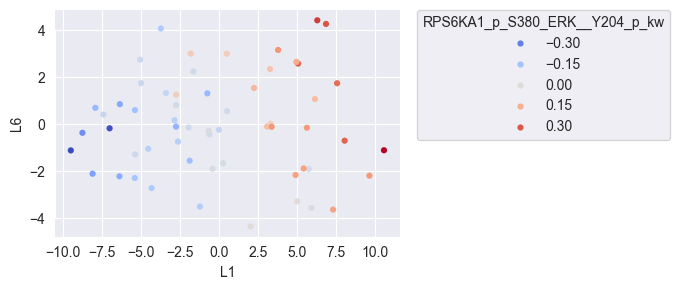

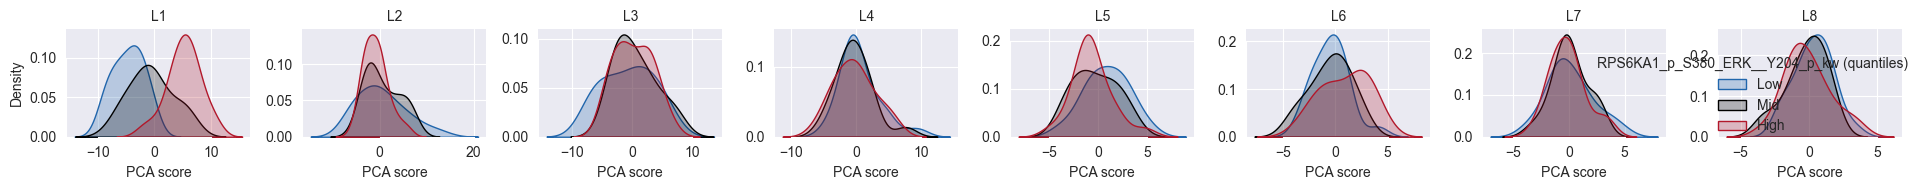

-----------------------------------------------------------


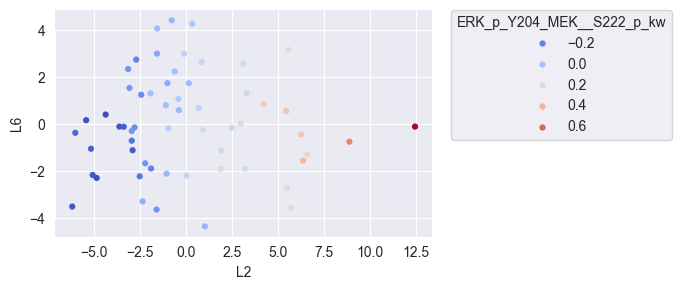

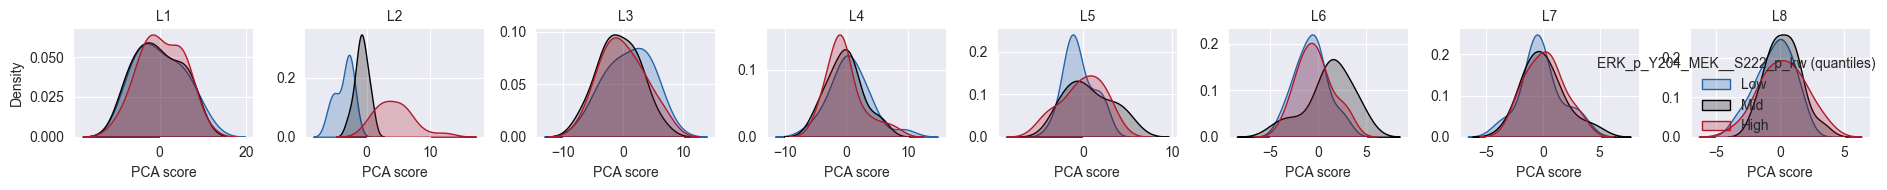

-----------------------------------------------------------


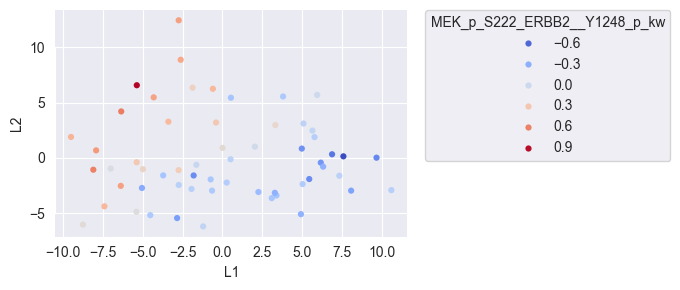

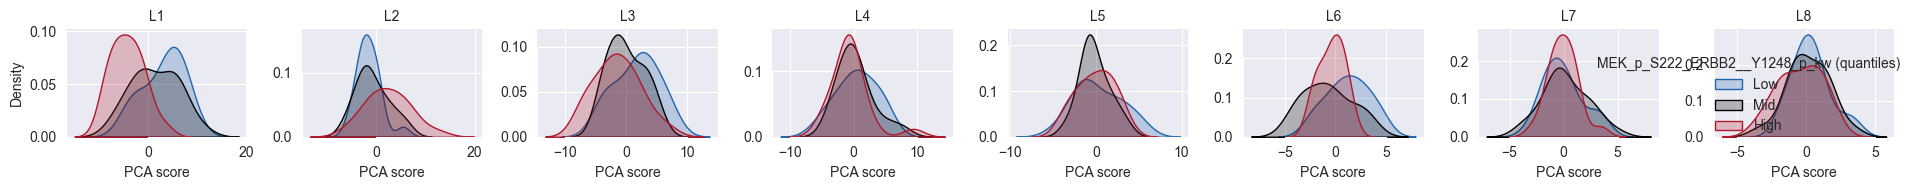

-----------------------------------------------------------


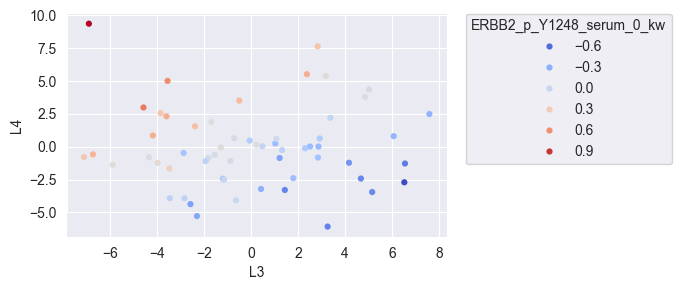

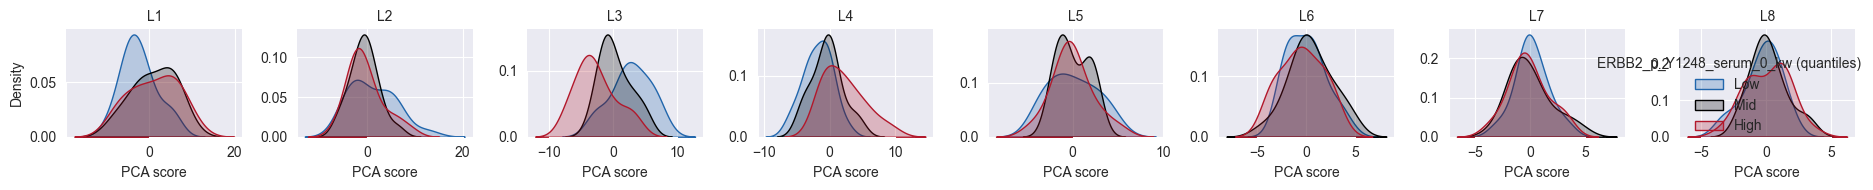

-----------------------------------------------------------


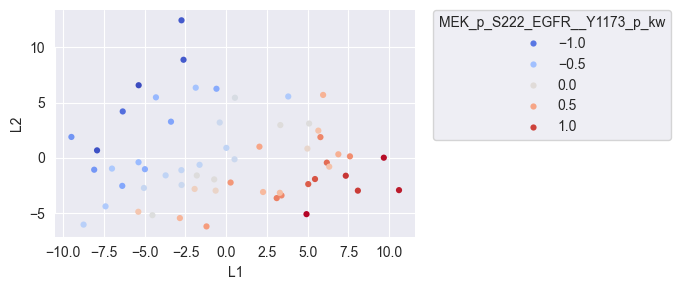

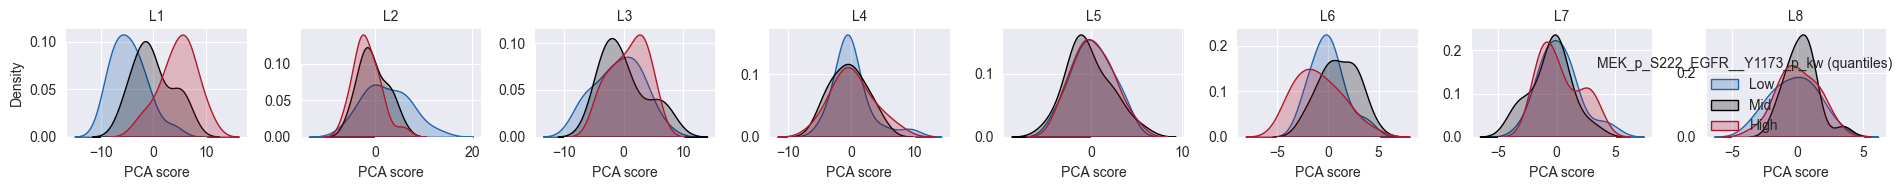

-----------------------------------------------------------


In [49]:
plot_parameters_on_embeddings(
    pca_embedding_df[pca_embedding_df.model == "EGFR_MAPK__logobs"],
    par_dev_df[par_dev_df.model == "EGFR_MAPK__logobs"],
    "cytof_init",
    top_params["base"]["cytof_init"],
    find_best_components=True,
    plot_hist_latent=True,
)

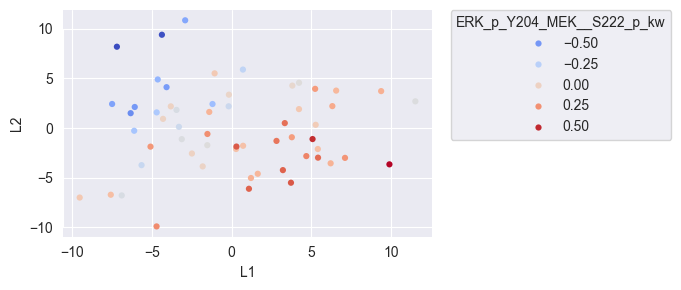

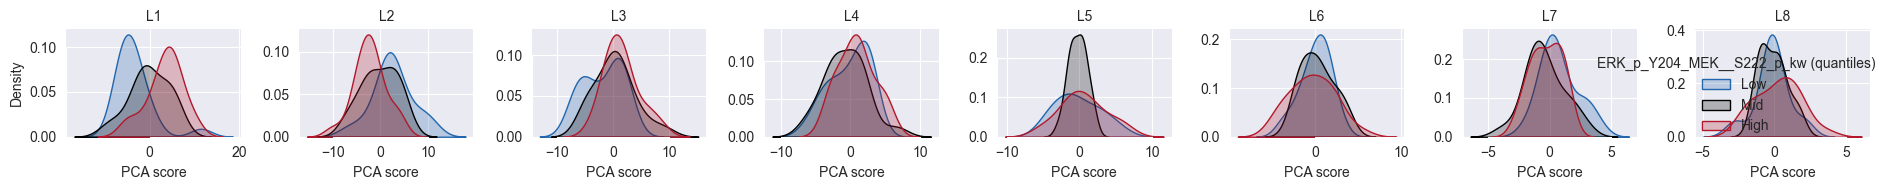

-----------------------------------------------------------


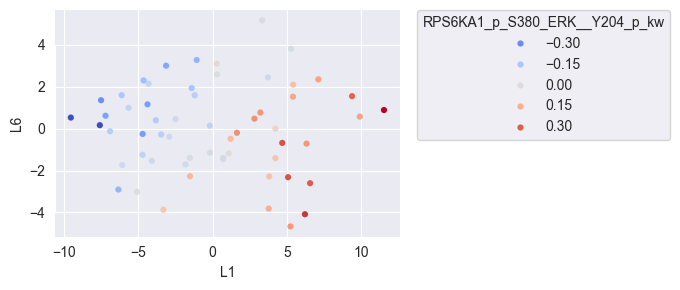

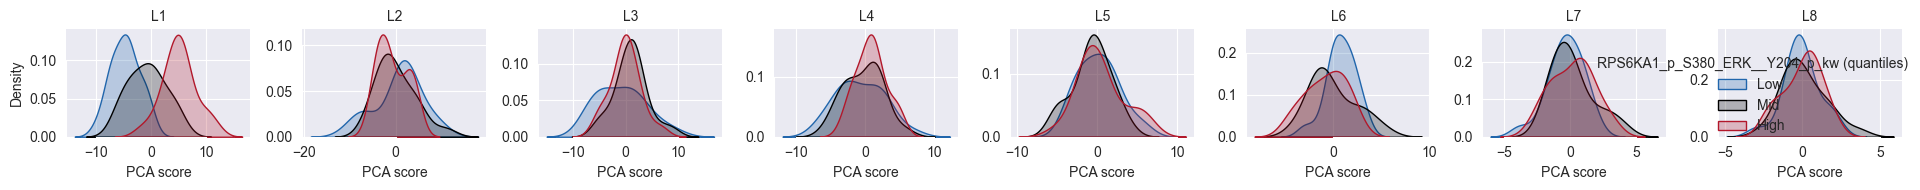

-----------------------------------------------------------


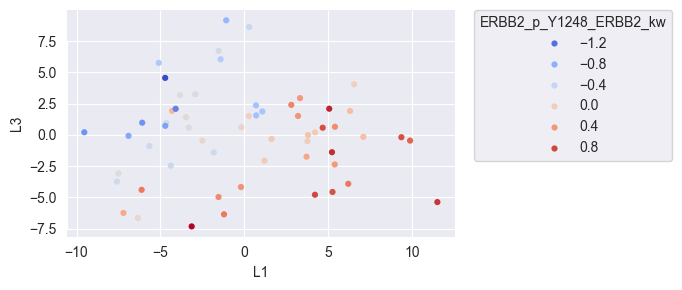

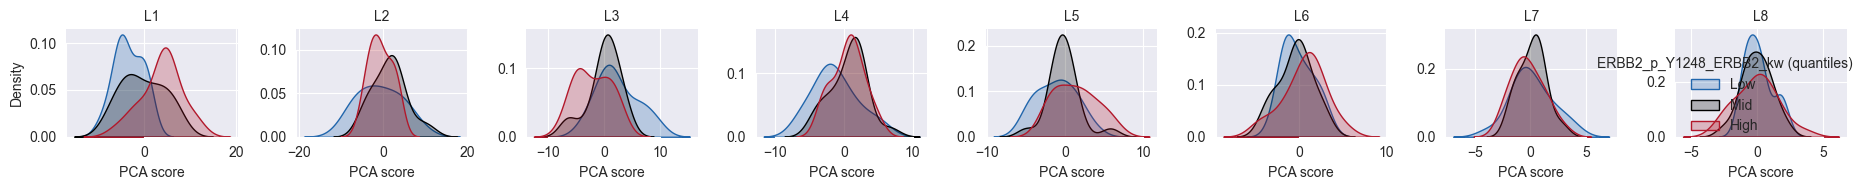

-----------------------------------------------------------


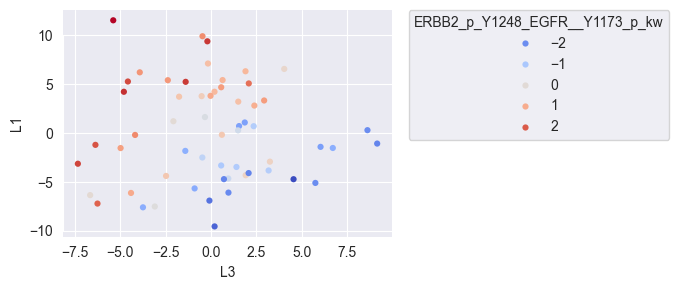

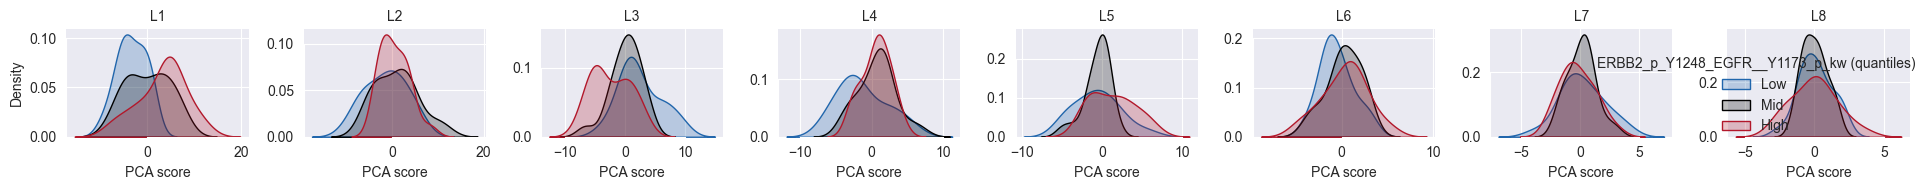

-----------------------------------------------------------


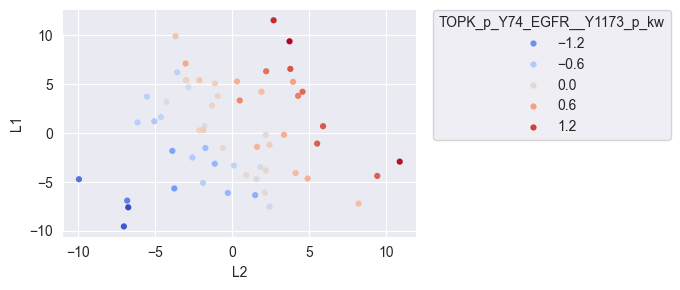

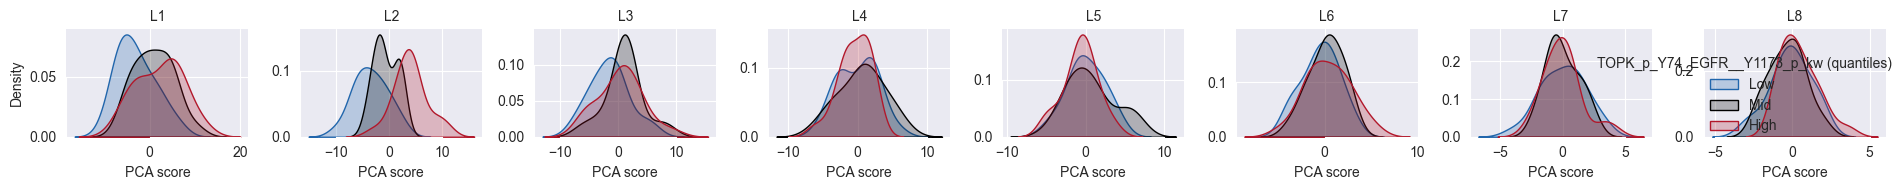

-----------------------------------------------------------


In [51]:
plot_parameters_on_embeddings(
    pca_embedding_df[pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    par_dev_df[par_dev_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    "cytof_init",
    top_params["tegfr"]["cytof_init"],
    find_best_components=True,
    plot_hist_latent=True,
)

In [53]:
top_params

{'base': {'cytof_init': array(['RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERK_p_Y204_MEK__S222_p_kw',
         'MEK_p_S222_ERBB2__Y1248_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
         'MEK_p_S222_EGFR__Y1173_p_kw'], dtype=object),
  'multimodal': array(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
         'MEK_p_S222_ERBB2__Y1248_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
         'EGFR_deg_EGF_0_kw'], dtype=object)},
 'tegfr': {'cytof_init': array(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
         'ERBB2_p_Y1248_ERBB2_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
         'TOPK_p_Y74_EGFR__Y1173_p_kw'], dtype=object),
  'multimodal': array(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
         'TOPK_p_Y74_EGFR__Y1173_p_kw', 'MEK_p_S222_ERK__Y204_p_kw',
         'MEK_p_S222_ERBB2__Y1248_p_kw'], dtype=object)}}

# Train classifier to predict subtype from latent embeddings

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

results = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    sub_df = pca_embedding_df[
        (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"] == "cytof_init")
    ]

    # Features = all PCA loadings starting with "L"
    X = sub_df[[col for col in sub_df.columns if str(col).startswith("L")]].values
    y = sub_df["luminalbasal"].values

    # Drop rows with NaNs if any
    mask = np.isfinite(X).all(axis=1) & pd.notnull(y)
    X = X[mask]
    y = y[mask]

    # Pipeline: standardise + logistic regression
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    )

    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

    results[model] = scores
    print(
        f"{model}: "
        f"fold accuracies = {np.round(scores, 3)}, "
        f"mean = {scores.mean():.3f} ± {scores.std():.3f}"
    )

EGFR_MAPK__logobs: fold accuracies = [0.484 0.516 0.484 0.495 0.522], mean = 0.500 ± 0.016
EGFR_MAPK__logobs_tegfr_aggavg: fold accuracies = [0.559 0.602 0.548 0.57  0.457], mean = 0.547 ± 0.049


In [68]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

models = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]

for model in models:
    print(f"\n=== Model: {model} ===")

    # subset data
    sub_df = pca_embedding_df[
        (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"] == "multimodal")
    ]

    # features: PCA components starting with 'L'
    X = sub_df[[col for col in sub_df.columns if str(col).startswith("L")]].values
    y = sub_df["luminalbasal"].values

    # drop rows with NaNs
    mask = np.isfinite(X).all(axis=1) & pd.notnull(y)
    X = X[mask]
    y = y[mask]

    # pipeline: standardise + multinomial logistic regression
    base_clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",  # explicit multinomial for >2 classes
            solver="lbfgs",
        ),
    )

    fold_accuracies = []
    fold_bal_acc = []
    cms = []

    y_all = []
    y_pred_all = []

    classes = np.unique(y)

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        clf = clone(base_clf)

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=classes)

        fold_accuracies.append(acc)
        fold_bal_acc.append(bal_acc)
        cms.append(cm)

        y_all.append(y_test)
        y_pred_all.append(y_pred)

        print(
            f"Fold {fold_idx}: "
            f"accuracy = {acc:.3f}, balanced_accuracy = {bal_acc:.3f}"
        )

    # concatenate all out-of-fold predictions for overall metrics
    y_all = np.concatenate(y_all)
    y_pred_all = np.concatenate(y_pred_all)

    overall_cm = confusion_matrix(y_all, y_pred_all, labels=classes)
    f1_macro = f1_score(y_all, y_pred_all, average="macro")
    f1_micro = f1_score(y_all, y_pred_all, average="micro")
    f1_per_class = f1_score(y_all, y_pred_all, average=None, labels=classes)

    print("\nPer-fold accuracy:")
    print("  ", np.round(fold_accuracies, 3))
    print(f"Mean accuracy = {np.mean(fold_accuracies):.3f} "
          f"± {np.std(fold_accuracies):.3f}")

    print("\nPer-fold balanced accuracy:")
    print("  ", np.round(fold_bal_acc, 3))
    print(f"Mean balanced accuracy = {np.mean(fold_bal_acc):.3f} "
          f"± {np.std(fold_bal_acc):.3f}")

    print("\nOverall confusion matrix (rows=true, cols=pred):")
    print("Classes order:", classes)
    print(overall_cm)

    print("\nPer-class F1 (same class order):")
    for cls, f1 in zip(classes, f1_per_class):
        print(f"  {cls}: {f1:.3f}")

    print(f"\nOverall F1 macro = {f1_macro:.3f}")
    print(f"Overall F1 micro = {f1_micro:.3f}")

    print("\nClassification report:")
    print(classification_report(y_all, y_pred_all))


=== Model: EGFR_MAPK__logobs ===
Fold 1: accuracy = 0.516, balanced_accuracy = 0.391
Fold 2: accuracy = 0.645, balanced_accuracy = 0.521
Fold 3: accuracy = 0.591, balanced_accuracy = 0.460
Fold 4: accuracy = 0.516, balanced_accuracy = 0.456
Fold 5: accuracy = 0.598, balanced_accuracy = 0.486

Per-fold accuracy:
   [0.516 0.645 0.591 0.516 0.598]
Mean accuracy = 0.573 ± 0.050

Per-fold balanced accuracy:
   [0.391 0.521 0.46  0.456 0.486]
Mean balanced accuracy = 0.463 ± 0.043

Overall confusion matrix (rows=true, cols=pred):
Classes order: ['Basal' 'Luminal' 'Normal']
[[ 83  90   3]
 [ 58 174   8]
 [ 12  27   9]]

Per-class F1 (same class order):
  Basal: 0.505
  Luminal: 0.655
  Normal: 0.265

Overall F1 macro = 0.475
Overall F1 micro = 0.573

Classification report:
              precision    recall  f1-score   support

       Basal       0.54      0.47      0.50       176
     Luminal       0.60      0.72      0.66       240
      Normal       0.45      0.19      0.26        48

   

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, accuracy_score

def train_and_plot_cm(X, y, class_names=None):
    """
    Train a multinomial logistic regression classifier and plot confusion matrix.

    Parameters
    ----------
    X : array (n_samples, n_features)
    y : array (n_samples,)
    class_names : list[str], optional
        Names of the classes for axis labels. If None, unique y values are used.
    """

    # Pipeline with scaler + logistic regression
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            solver="lbfgs"
        )
    )

    # Fit + predict on the same set (no CV)
    clf.fit(X, y)
    y_pred = clf.predict(X)

    # Accuracy
    acc = accuracy_score(y, y_pred)
    print(f"Accuracy: {acc:.3f}")

    # Confusion matrix
    classes = np.unique(y)
    if class_names is None:
        class_names = classes
    cm = confusion_matrix(y, y_pred, labels=class_names)
    def cm_to_percent(cm):
        return cm / cm.sum(axis=1, keepdims=True) * 100
    cm = cm_to_percent(cm)


    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")

    # Show percentages inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:.1f}%",
                ha="center", va="center", color="black"
            )

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")

    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

    return clf, cm, acc


=== Model: EGFR_MAPK__logobs (samples == 'all') ===
Fold 1 accuracy: 0.583
Fold 2 accuracy: 0.750
Fold 3 accuracy: 0.583
Fold 4 accuracy: 0.727
Fold 5 accuracy: 0.636

Mean CV accuracy: 0.656 ± 0.071
Overall CV accuracy (all folds combined): 0.655
Confusion matrix (counts, rows=true, cols=pred):
Class order: ['Normal', 'Luminal', 'Basal']
[[ 1  3  2]
 [ 3 22  5]
 [ 2  5 15]]


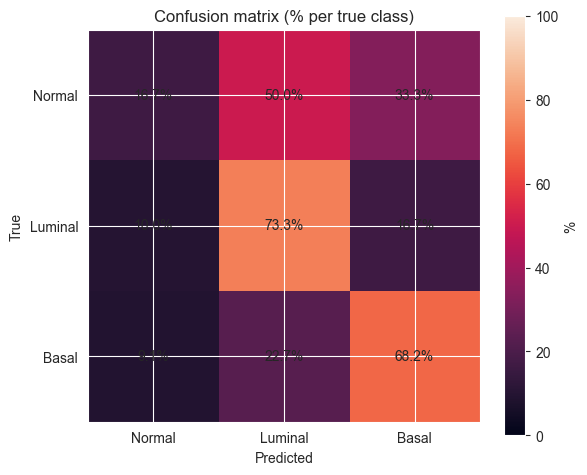


=== Model: EGFR_MAPK__logobs_tegfr_aggavg (samples == 'all') ===
Fold 1 accuracy: 0.583
Fold 2 accuracy: 0.833
Fold 3 accuracy: 0.750
Fold 4 accuracy: 0.545
Fold 5 accuracy: 0.727

Mean CV accuracy: 0.688 ± 0.108
Overall CV accuracy (all folds combined): 0.690
Confusion matrix (counts, rows=true, cols=pred):
Class order: ['Normal', 'Luminal', 'Basal']
[[ 1  2  3]
 [ 2 23  5]
 [ 0  6 16]]


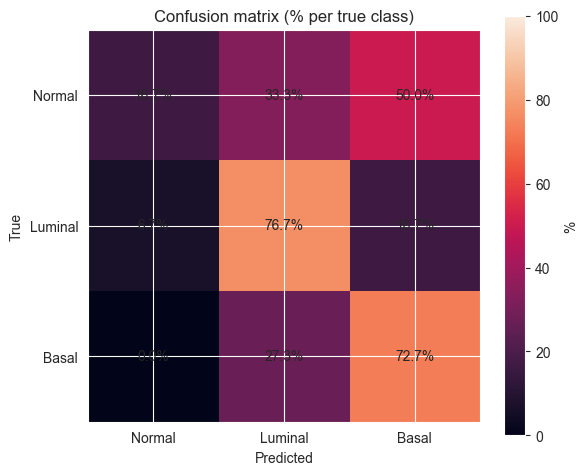

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.base import clone

CLASS_ORDER = ["Normal", "Luminal", "Basal"]  # desired order

def plot_cm_percent(cm, labels):
    """Plot row-normalised confusion matrix in %."""
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_pct, vmin=0, vmax=100)

    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            ax.text(j, i, f"{cm_pct[i, j]:.1f}%",
                    ha="center", va="center")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion matrix (% per true class)")

    fig.colorbar(im, label="%")
    plt.tight_layout()
    plt.show()

def run_cv_samples_all(pca_embedding_df, model_name, context_name):
    # subset: one model, cytof_init, and samples == "all"
    sub_df = pca_embedding_df[
        (pca_embedding_df["model"] == model_name)
        & (pca_embedding_df["context"] == context_name)
        & (pca_embedding_df["samples"] == "all")
    ].copy()

    # features and labels
    X = sub_df[[col for col in sub_df.columns if col.startswith("L")]].values
    y = sub_df["luminalbasal"].values

    # pick a sensible number of folds (don't exceed smallest class size)
    min_per_class = sub_df["luminalbasal"].value_counts().min()
    n_splits = min(5, min_per_class)  # at least 2 in practice
    if n_splits < 2:
        raise ValueError("Not enough samples per class to run CV.")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    base_clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            solver="lbfgs",
        ),
    )

    y_true_all = []
    y_pred_all = []

    print(f"\n=== Model: {model_name} (samples == 'all') ===")
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        clf = clone(base_clf)
        clf.fit(X[train_idx], y[train_idx])
        y_pred = clf.predict(X[test_idx])

        acc = accuracy_score(y[test_idx], y_pred)
        fold_accs.append(acc)
        print(f"Fold {fold} accuracy: {acc:.3f}")

        y_true_all.append(y[test_idx])
        y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    cm = confusion_matrix(y_true_all, y_pred_all, labels=CLASS_ORDER)
    overall_acc = accuracy_score(y_true_all, y_pred_all)

    print(f"\nMean CV accuracy: {np.mean(fold_accs):.3f} "
          f"± {np.std(fold_accs):.3f}")
    print(f"Overall CV accuracy (all folds combined): {overall_acc:.3f}")
    print("Confusion matrix (counts, rows=true, cols=pred):")
    print("Class order:", CLASS_ORDER)
    print(cm)

    plot_cm_percent(cm, CLASS_ORDER)
    return cm, overall_acc, fold_accs

# Run for both models
for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    cm, acc, fold_accs = run_cv_samples_all(pca_embedding_df, model, "cytof_init")


=== Model: EGFR_MAPK__logobs (samples == 'all') ===
Fold 1 accuracy: 0.750
Fold 2 accuracy: 0.833
Fold 3 accuracy: 0.750
Fold 4 accuracy: 0.909
Fold 5 accuracy: 0.909

Mean CV accuracy: 0.830 ± 0.071
Overall CV accuracy (all folds combined): 0.828
Confusion matrix (counts, rows=true, cols=pred):
Class order: ['Normal', 'Luminal', 'Basal']
[[ 4  1  1]
 [ 0 28  2]
 [ 0  6 16]]


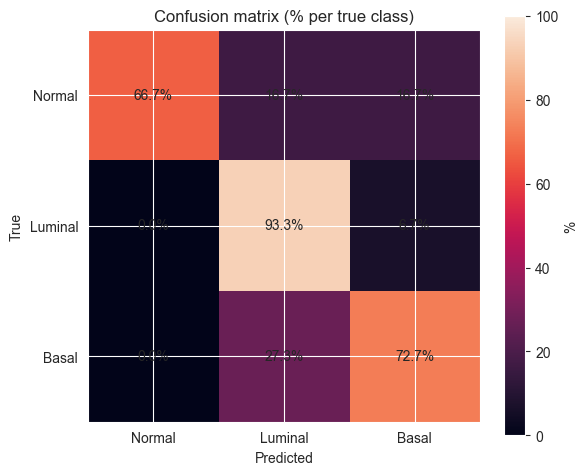


=== Model: EGFR_MAPK__logobs_tegfr_aggavg (samples == 'all') ===
Fold 1 accuracy: 0.750
Fold 2 accuracy: 0.917
Fold 3 accuracy: 0.750
Fold 4 accuracy: 0.909
Fold 5 accuracy: 0.909

Mean CV accuracy: 0.847 ± 0.079
Overall CV accuracy (all folds combined): 0.845
Confusion matrix (counts, rows=true, cols=pred):
Class order: ['Normal', 'Luminal', 'Basal']
[[ 4  0  2]
 [ 0 27  3]
 [ 0  4 18]]


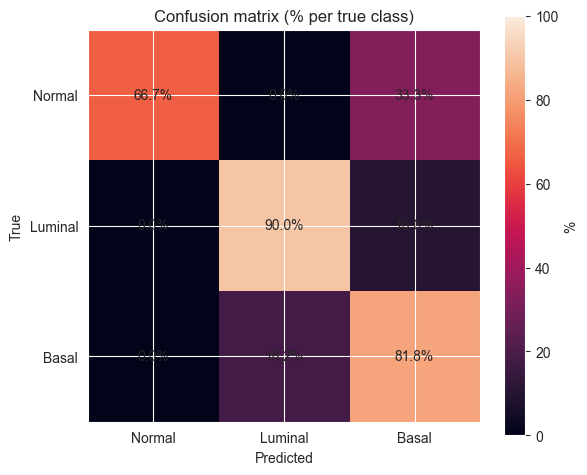

In [104]:
# Run for both models
for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    cm, acc, fold_accs = run_cv_samples_all(pca_embedding_df, model, "multimodal")